In [7]:
from pathlib import Path
import random
import numpy as np

import pandas as pd
from PIL import Image, ImageFilter, ImageOps
from IPython.display import display

# Notebook is in .../handwriting_forge_project/notebooks/
PROJECT_ROOT = Path.cwd().parent

IAM_META_PATH = PROJECT_ROOT / "data" / "processed" / "metadata" / "iam_metadata.csv"
EMURU_SENT_META_PATH = PROJECT_ROOT / "data" / "processed" / "metadata" / "emuru_sentences_metadata.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IAM_META_PATH:", IAM_META_PATH)
print("EMURU_SENT_META_PATH:", EMURU_SENT_META_PATH)


PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
IAM_META_PATH: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/iam_metadata.csv
EMURU_SENT_META_PATH: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/emuru_sentences_metadata.csv


In [2]:
iam_df = pd.read_csv(IAM_META_PATH)
emuru_sent_df = pd.read_csv(EMURU_SENT_META_PATH)

print("IAM rows:", len(iam_df))
print("Emuru sentence rows:", len(emuru_sent_df))

iam_df.head(2), emuru_sent_df.head(2)

IAM rows: 6482
Emuru sentence rows: 4407


(                     filepath source    label  \
 0  data/raw/iam/iam_00000.png    iam  genuine   
 1  data/raw/iam/iam_00001.png    iam  genuine   
 
                                    text  idx  
 0  put down a resolution on the subject    0  
 1    and he is to be backed by Mr. Will    1  ,
    iam_index                iam_filepath  \
 0          0  data/raw/iam/iam_00000.png   
 1          1  data/raw/iam/iam_00001.png   
 
                                iam_text  num_chunks  \
 0  put down a resolution on the subject           4   
 1    and he is to be backed by Mr. Will           5   
 
                                       chunks_text  \
 0   put down || a resolution || on the || subject   
 1  and he || is to || be backed || by Mr. || Will   
 
                            emuru_sentence_filepath  \
 0  data/raw/emuru/sentences/iam_00000_sentence.png   
 1  data/raw/emuru/sentences/iam_00001_sentence.png   
 
                              style_text  
 0  put down a resolut

In [8]:
def build_paper_texture(
    iam_df: pd.DataFrame,
    project_root: Path,
    num_sources: int = 200,
    size=(1024, 256),
    percentile: int = 90,
    seed: int = 42,
) -> Image.Image:
    """
    Build a generic paper texture from IAM by taking a high percentile
    across many line images, which suppresses dark strokes and keeps
    the light background.

    Uses NumPy for a real 'paper' look instead of blurred text.
    """
    rng = random.Random(seed)
    candidates = iam_df["filepath"].dropna().astype(str).tolist()
    if not candidates:
        raise ValueError("No IAM filepaths found in iam_df['filepath'].")

    sample_paths = rng.sample(candidates, k=min(num_sources, len(candidates)))

    stack = []
    for rel in sample_paths:
        abs_path = project_root / rel
        try:
            img = Image.open(abs_path).convert("L")  # grayscale
        except Exception as e:
            print(f"Skipping {abs_path} due to error: {e}")
            continue

        img = img.resize(size, Image.BICUBIC)
        arr = np.array(img, dtype="float32")
        stack.append(arr)

    if not stack:
        raise RuntimeError("Could not build paper texture (no valid images).")

    stack = np.stack(stack, axis=0)  # (N, H, W)

    # High percentile → background only (text is darker, so lower percentile)
    bg_arr = np.percentile(stack, percentile, axis=0)

    # Optional: add tiny noise to avoid looking too flat
    noise = np.random.normal(loc=0.0, scale=3.0, size=bg_arr.shape)
    bg_arr = np.clip(bg_arr + noise, 0, 255).astype("uint8")

    bg_img = Image.fromarray(bg_arr, mode="L").convert("RGB")
    return bg_img


In [11]:
def load_iam_image(iam_rel_path: str | Path) -> Image.Image:
    abs_path = PROJECT_ROOT / Path(iam_rel_path)
    return Image.open(abs_path).convert("RGB")


def load_emuru_sentence_image(sent_rel_path: str | Path) -> Image.Image:
    abs_path = PROJECT_ROOT / Path(sent_rel_path)
    return Image.open(abs_path).convert("L")  # grayscale is enough


def emuru_on_paper_preview(
    emuru_img_gray: Image.Image,
    paper_texture: Image.Image,
    ink_color=(40, 40, 40),
) -> Image.Image:
    """
    Take a white-background Emuru sentence (grayscale) and render it
    on the given paper texture. Returns a new PIL.Image (not saved).
    """
    # Resize paper to match Emuru size
    paper = paper_texture.resize(emuru_img_gray.size, Image.BICUBIC).convert("RGB")

    # emu: 0=black (ink), 255=white (bg)
    mask = ImageOps.invert(emuru_img_gray)

    # Simple contrast-ish tweak
    def enhance(v):
        v = max(0, v - 40)
        v = int(v * 255 / 215)
        return max(0, min(255, v))

    mask = mask.point(enhance)

    # Ink layer: solid ink_color
    ink_layer = Image.new("RGB", emuru_img_gray.size, ink_color)

    # Composite: where mask is strong -> ink_layer, else -> paper
    out = Image.composite(ink_layer, paper, mask)
    return out


IAM index: 466
IAM filepath: data/raw/iam/iam_00466.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_00466_sentence.png

TEXT:
able to bear them . Mr. Brown

Original IAM line:


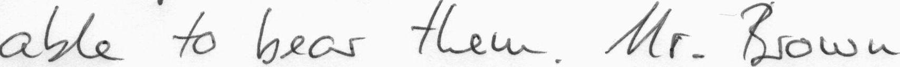

Emuru sentence (white background):


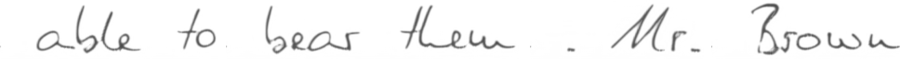

Emuru sentence on generic IAM-style paper (preview only, not saved):


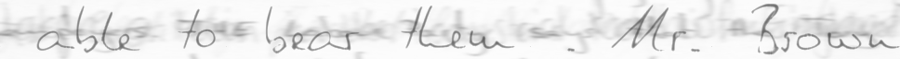

IAM index: 2375
IAM filepath: data/raw/iam/iam_02375.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_02375_sentence.png

TEXT:
Office Savings Bank shows how wrong that

Original IAM line:


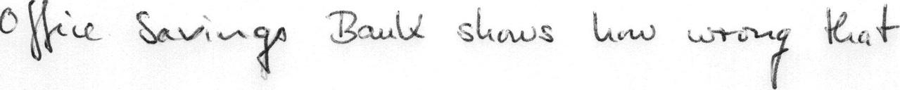

Emuru sentence (white background):


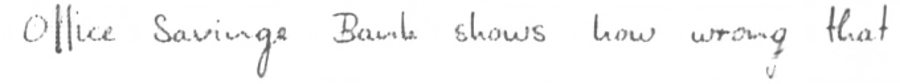

Emuru sentence on generic IAM-style paper (preview only, not saved):


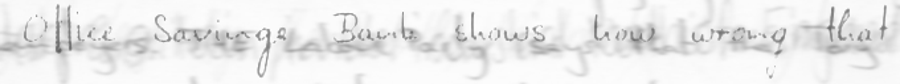

IAM index: 769
IAM filepath: data/raw/iam/iam_00769.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_00769_sentence.png

TEXT:
today , including Lord Russell , Lady Russell ,

Original IAM line:


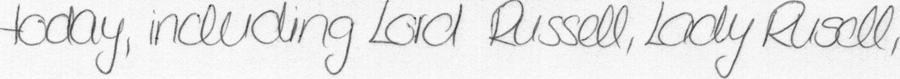

Emuru sentence (white background):


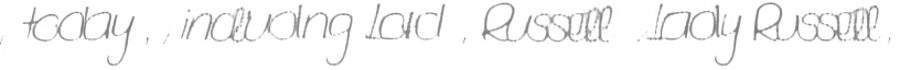

Emuru sentence on generic IAM-style paper (preview only, not saved):


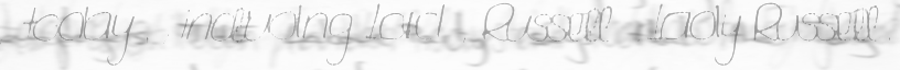

IAM index: 3559
IAM filepath: data/raw/iam/iam_03559.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_03559_sentence.png

TEXT:
business . He plays an aspiring actor - a

Original IAM line:


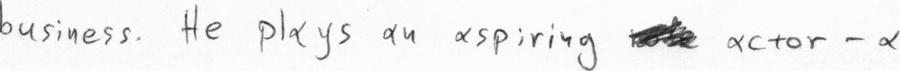

Emuru sentence (white background):


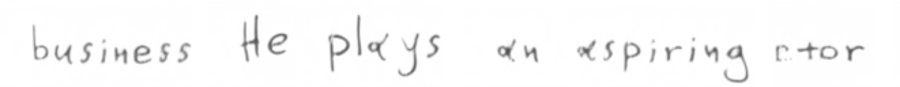

Emuru sentence on generic IAM-style paper (preview only, not saved):


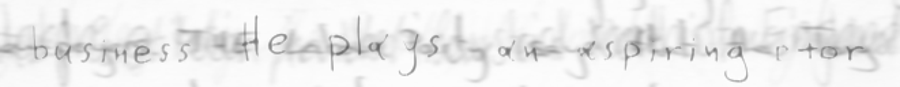

IAM index: 2365
IAM filepath: data/raw/iam/iam_02365.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_02365_sentence.png

TEXT:
" jelly-boned . " He promises to preserve federation

Original IAM line:


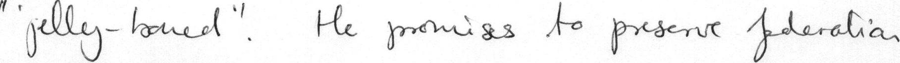

Emuru sentence (white background):


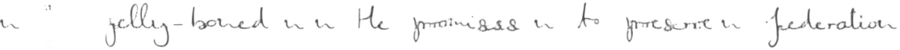

Emuru sentence on generic IAM-style paper (preview only, not saved):


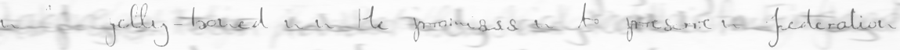

In [10]:
def show_example_with_paper(row, paper_texture: Image.Image):
    text = row["iam_text"]
    iam_rel = row["iam_filepath"]
    emuru_rel = row["emuru_sentence_filepath"]

    print("=" * 100)
    print("IAM index:", row.get("iam_index", "N/A"))
    print("IAM filepath:", iam_rel)
    print("Emuru sentence filepath:", emuru_rel)
    print("\nTEXT:")
    print(text)
    print("=" * 100)

    # Load images
    iam_img = load_iam_image(iam_rel)
    emu_gray = load_emuru_sentence_image(emuru_rel)

    # Make previews not too huge
    target_width = 900
    def resize_keep_aspect(img, target_w):
        w, h = img.size
        if w == 0:
            return img
        new_h = int(h * (target_w / w))
        return img.resize((target_w, new_h))

    iam_preview = resize_keep_aspect(iam_img, target_width)
    emu_white_preview = resize_keep_aspect(emu_gray.convert("RGB"), target_width)

    # Paper composite (in memory)
    emu_paper = emuru_on_paper_preview(emu_gray, paper_texture)
    emu_paper_preview = resize_keep_aspect(emu_paper, target_width)

    print("\nOriginal IAM line:")
    display(iam_preview)

    print("Emuru sentence (white background):")
    display(emu_white_preview)

    print("Emuru sentence on generic IAM-style paper (preview only, not saved):")
    display(emu_paper_preview)


# Show a few random samples
random.seed(123)
n_examples = 5

indices = random.sample(range(len(emuru_sent_df)), k=min(n_examples, len(emuru_sent_df)))
for idx in indices:
    row = emuru_sent_df.iloc[idx]
    show_example_with_paper(row, paper_texture)
